In [1]:
import tensorflow as tf
import numpy as np
print("TF:", tf.__version__)
# 1) Scalars, vectors, matrices, tensors
scalar = tf.constant(7) # rank-0
vector = tf.constant([10, 20, 30]) # rank-1
matrix = tf.constant([[1., 2.], [3., 4.]]) # rank-2
tensor = tf.constant([[[1],[2]], [[3],[4]]]) # rank-3 (2x2x1)
print(scalar.shape, vector.shape, matrix.shape, tensor.shape)
# 2) Dtypes and casting
x = tf.constant([1.7, 7.4]) # float32 default
y = tf.constant([7, 10]) # int32 default
x16 = tf.cast(x, tf.float16) # reduced precision floats
y32 = tf.cast(y, tf.float32) # cast ints → floats
# 3) Indexing and shaping
rank2 = tf.constant([[10, 7], [3, 4]])
last_col = rank2[:, -1] # column slice
expanded = tf.expand_dims(rank2, -1) # add channel-like axis
squeezed = tf.squeeze(expanded, axis=-1)
# 4) Broadcasting & basic ops
A = tf.constant([[10., 7.], [3., 4.]])
print("A+10:\n", A + 10)
print("A*2:\n", A * 2)
# 5) Matrix multiplication rules (inner dims match)
X = tf.constant([[1, 2], [3, 4], [5, 6]], dtype=tf.float32) # (3x2)
Y = tf.constant([[7, 8], [9, 10], [11, 12]], dtype=tf.float32) # (3x2)
XtY = tf.matmul(X, tf.transpose(Y)) # (3x2) @ (2x3) -> (3x3)
# 6) Aggregations
E = tf.constant(np.random.randint(0, 100, size=10))
print("min:", tf.reduce_min(E).numpy(),
"max:", tf.reduce_max(E).numpy(),
"mean:", tf.reduce_mean(tf.cast(E, tf.float32)).numpy(),
"sum:", tf.reduce_sum(E).numpy())
# 7) One-hot encoding
idx = tf.constant([0, 1, 2, 3])
oh = tf.one_hot(idx, depth=4)
# 8) NumPy interop
arr = np.array([3., 7., 10.])
t = tf.constant(arr) # NumPy -> Tensor
back_to_np = t.numpy() # Tensor -> NumPy
print("OK")

TF: 2.20.0
() (3,) (2, 2) (2, 2, 1)
A+10:
 tf.Tensor(
[[20. 17.]
 [13. 14.]], shape=(2, 2), dtype=float32)
A*2:
 tf.Tensor(
[[20. 14.]
 [ 6.  8.]], shape=(2, 2), dtype=float32)
min: 19 max: 86 mean: 56.2 sum: 562
OK


Epoch 1/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 18.0076 - mae: 18.0076 
Epoch 2/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 14.3088 - mae: 14.3088
Epoch 3/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 9.7152 - mae: 9.7152
Epoch 4/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 8.7616 - mae: 8.7616
Epoch 5/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 9.0457 - mae: 9.0457
Epoch 6/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 9.3447 - mae: 9.3447
Epoch 7/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 7.9899 - mae: 7.9899
Epoch 8/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 9.0785 - mae: 9.0785
Epoch 9/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 8.3686 - mae: 8.3686
Epoch 10/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 9.0968 - mae: 9.0968
Epoch 11/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 9.8179 - mae: 9.8179  
Epoch 12/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 9.8431 - mae: 9.8431
Epoch 13/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2

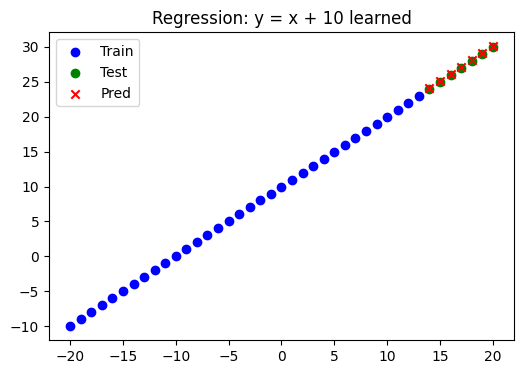

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
# Synthetic linear data
X = np.arange(-20, 21, 1, dtype=np.float32) 
y = X + 10
# Train/test split (simple)
X_train, y_train = X[:34], y[:34]
X_test, y_test = X[34:], y[34:]
# 1) CREATE
model = tf.keras.Sequential([
 tf.keras.layers.Input(shape=(1,)),
 tf.keras.layers.Dense(1) # linear output for regression
])
# 2) COMPILE
model.compile(
 loss="mae",
 optimizer=tf.keras.optimizers.SGD(learning_rate=0.03),
 metrics=["mae"]
)
# 3) FIT
history = model.fit(X_train, y_train, epochs=250, verbose=1)
# Evaluate
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print("Test MAE:", mae)
# Predict and visualize
y_pred = model.predict(X_test).squeeze()
plt.figure(figsize=(6,4))
plt.scatter(X_train, y_train, c='b', label='Train')
plt.scatter(X_test, y_test, c='g', label='Test')
plt.scatter(X_test, y_pred, c='r', marker="x", label='Pred')
plt.legend(); plt.title("Regression: y = x + 10 learned")
plt.show()

Train - Test and then Predict

Ways to fix the prediction
1.Adding Layers
2.Changing the way of activiation

Train shapes: (2400, 2) (2400,)
Test shapes: (600, 2) (600,)
Epoch 1/200
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6000 - loss: 0.6720 
Epoch 2/200
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9050 - loss: 0.4270
Epoch 3/200
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 904us/step - accuracy: 0.9979 - loss: 0.1100
Epoch 4/200
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9983 - loss: 0.0403
Epoch 5/200
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9992 - loss: 0.0221
Epoch 6/200
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 970us/step - accuracy: 0.9967 - loss: 0.0202
Epoch 7/200
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9992 - loss: 0.0107  
Epoch 8/200
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9979 - loss: 0.0114  
Epoch 9/200
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 978us/step - accuracy: 0.9962 - loss: 0.0127
Epoch 10/200
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9962 - loss: 0.0128   
Epoch 11/200
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9996 - l

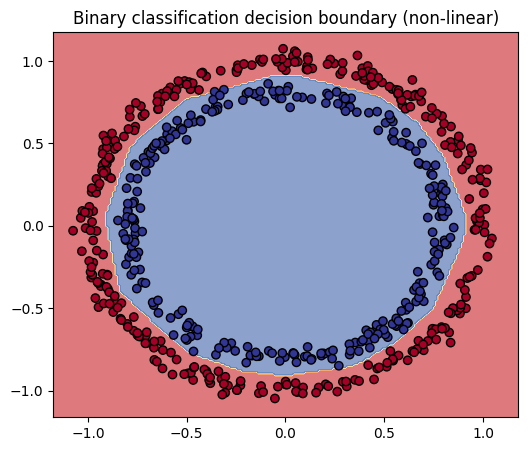

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
# Non-linear separable data
X, y = make_circles(n_samples=3000, noise=0.03, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
 random_state=42)

print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes:", X_test.shape, y_test.shape)
# x data means actual data
# y data means labels or classicification (cat or dog?)
# 1) CREATE (use non-linear activations + sigmoid output)
model = tf.keras.Sequential([
 tf.keras.layers.Input(shape=(2,)),
 tf.keras.layers.Dense(16, activation="relu"),  #this kind of layer is called hidden layer
 tf.keras.layers.Dense(16, activation="relu"),  #this kind of layer is called hidden layer
 tf.keras.layers.Dense(1, activation="sigmoid") # output layer for binary classification
])
# 2) COMPILE
model.compile(
 loss="binary_crossentropy", # what are we trying to minimize? (log loss for binary classification)
                             # binary crossentropy is the most common loss function for binary classification problems (yes or no, cat or dog, etc.)
 optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), # how short of a distance are we taking in the direction of the loss minimum? Keep it short but too short and we might never get there)
                                                         # (Adam is a popular optimizer that adapts the learning rate)
 metrics=["accuracy"]
)
# 3) FIT
history = model.fit(X_train, y_train, epochs=200, verbose=1) #epochs = how many times we go through the entire training data (more epochs can lead to better learning but also overfitting)
                                                            #verbose=0 means we won't see the training progress in the console
# Evaluate
loss, acc = model.evaluate(X_test, y_test, verbose=0) #evaluate the model on the test set and get the loss and accuracy
print(f"Test accuracy: {acc:.3f}")
# Visualize decision boundary
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.1, X[:,0].max()+0.1, 200), # create a grid of points to evaluate the model on for visualization
 np.linspace(X[:,1].min()-0.1, X[:,1].max()+0.1, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = model.predict(grid, verbose=0).reshape(xx.shape)
plt.figure(figsize=(6,5))
plt.contourf(xx, yy, (probs>0.5).astype(int), cmap=plt.cm.RdYlBu, alpha=0.6)
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap=plt.cm.RdYlBu, edgecolor='k')
plt.title("Binary classification decision boundary (non-linear)")
plt.show()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train shapes: (60000, 28, 28) (60000,)
Test shapes: (10000, 28, 28) (10000,)
Epoch 1/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8203 - loss: 0.4976 - val_accuracy: 0.8487 - val_loss: 0.4205
Epoch 2/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8636 - loss: 0.3723 - val_accuracy: 0.8635 - val_loss: 0.3638
Epoch 3/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8755 - loss: 0.3369 - val_accuracy: 0.8692 - val_loss: 0.3552
Epoch 4/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8833 - loss: 0.3137 - val_accuracy: 0.8687 - val_loss: 0.3721
Epoch 5/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8897 - loss: 0.2957 - val_accuracy: 0.8807 - val_loss: 0.3334
Epoch 6/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8971 - loss: 0.27

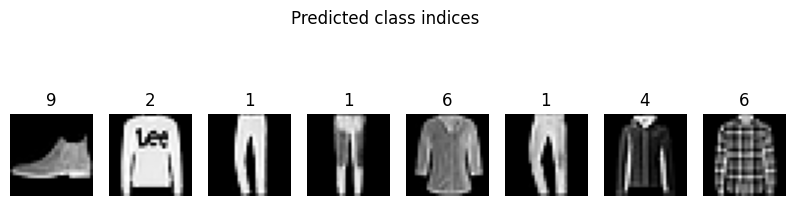

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
# Load Fashion-MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
print("Train shapes:", x_train.shape, y_train.shape)
print("Test shapes:", x_test.shape, y_test.shape)   
# Normalize to [0,1]
x_train = x_train.astype("float32")/255.0 # convert to float and scale pixel values to [0,1]
x_test = x_test.astype("float32")/255.0 # convert to float and scale pixel values to [0,1]
# 1) CREATE (flatten > Dense ReLU > Dense softmax)
model = tf.keras.Sequential([
 tf.keras.layers.Input(shape=(28, 28)), # input layer for 28x28 images
 tf.keras.layers.Flatten(), # flatten 28x28 → 784 vector
 tf.keras.layers.Dense(128, activation="relu"), # hidden layer with ReLU activation
 tf.keras.layers.Dense(128, activation="relu"), # hidden layer with ReLU activation
 tf.keras.layers.Dense(128, activation="relu"), # hidden layer with ReLU activation
 tf.keras.layers.Dense(10, activation="softmax") # output layer for 10 classes with softmax activation
])
# 2) COMPILE
model.compile(
 loss="sparse_categorical_crossentropy", # labels are ints, not one-hot
 optimizer="adam",
 metrics=["accuracy"]
)
# 3) FIT
history = model.fit(x_train, y_train, epochs=15, validation_split=0.1, verbose=1) # train for 10 epochs and use 10% of training data for validation
# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", acc)
# Show a few preds
preds = model.predict(x_test[:8]).argmax(axis=1)
plt.figure(figsize=(10,3))
for i in range(8):
 plt.subplot(1,8,i+1)
 plt.imshow(x_test[i], cmap='gray')
 plt.title(int(preds[i]))
 plt.axis('off')
plt.suptitle("Predicted class indices"); plt.show()


In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
# Use Fashion-MNIST but map 2 classes to a binary task (e.g., class 9=Ankle boot vs 7=Sneaker)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
# Keep only classes 7 and 9
train_mask = np.isin(y_train, [7, 9])
test_mask = np.isin(y_test, [7, 9])
x_train = x_train[train_mask][..., None]/255.0
y_train = (y_train[train_mask] == 9).astype(np.float32) # 1 if class 9 else 0
x_test = x_test[test_mask][..., None]/255.0
y_test = (y_test[test_mask] == 9).astype(np.float32)
# 1) CREATE (small CNN)
model = tf.keras.Sequential([
 tf.keras.layers.Input(shape=(28,28,1)),
 tf.keras.layers.Conv2D(16, 3, activation="relu"),
 tf.keras.layers.MaxPool2D(),
 tf.keras.layers.Conv2D(32, 3, activation="relu"),
 tf.keras.layers.MaxPool2D(),
 tf.keras.layers.Flatten(),
 tf.keras.layers.Dense(64, activation="relu"),
 tf.keras.layers.Dense(1, activation="sigmoid")
])
# 2) COMPILE
model.compile(
 loss="binary_crossentropy",
 optimizer="adam",
 metrics=["accuracy"]
)
# 3) FIT
history = model.fit(x_train, y_train, epochs=5, validation_split=0.1, verbose=0)
# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", acc)


Test accuracy: 0.9710000157356262


In [6]:
import ssl
import certifi

ssl._create_default_https_context = ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

import tensorflow as tf
from tensorflow.keras import layers, models
# Data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
# Keep classes 0,1,2 only
mask_train = (y_train < 3).flatten()
mask_test = (y_test < 3).flatten()
x_train = x_train[mask_train].astype("float32")/255.0
y_train = y_train[mask_train].flatten()
x_test = x_test[mask_test].astype("float32")/255.0
y_test = y_test[mask_test].flatten()
# Small CNN model
model = models.Sequential([
layers.Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(32,32,3)),
layers.MaxPooling2D(),
layers.Conv2D(64, (3,3), activation="relu", padding="same"),
layers.MaxPooling2D(),
layers.Conv2D(128, (3,3), activation="relu", padding="same"),
layers.MaxPooling2D(),
layers.Flatten(),
layers.Dense(64, activation="relu"),
layers.Dense(3, activation="softmax")
])
model.compile(
optimizer="adam",
loss="sparse_categorical_crossentropy",
metrics=["accuracy"]
)
# Train
history = model.fit(
x_train, y_train,
epochs=10,
batch_size=64,
validation_split=0.01,
verbose=1
)
# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy (tiny CNN):", acc)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


d:\LAB\2026\Spring\Implementing_IoT_Pipeline\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Epoch 1/10


d:\LAB\2026\Spring\Implementing_IoT_Pipeline\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7384 - loss: 0.6244 - val_accuracy: 0.8200 - val_loss: 0.4726
Epoch 2/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8526 - loss: 0.3815 - val_accuracy: 0.8600 - val_loss: 0.3545
Epoch 3/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8711 - loss: 0.3245 - val_accuracy: 0.8933 - val_loss: 0.2840
Epoch 4/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8946 - loss: 0.2752 - val_accuracy: 0.9067 - val_loss: 0.3183
Epoch 5/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9085 - loss: 0.2400 - val_accuracy: 0.9000 - val_loss: 0.3063
Epoch 6/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9199 - loss: 0.2111 - val_accuracy: 0.8800 - val_loss: 0.3343
Epoch 7/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9321 - loss: 0.1780 - val_accuracy: 0.9000 - val_loss: 0.2777
Epoch 8/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9420 - loss: 0.1554 - val_accuracy: 0.926